Classificazione SVM

In [1]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler


In [7]:
data = load_iris()
X = data.data
y = data.target

display(pd.DataFrame(X, columns=data.feature_names))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [6]:
display(pd.DataFrame(y, columns=["target"]))

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
svc_linear = SVC(kernel="linear", C=1.0, random_state=42)
svc_linear.fit(X_scaled, y)
y_pred_linear = svc_linear.predict(X_scaled)

In [10]:
svc_rbf = SVC(kernel="rbf", C=1.0, random_state=42)
svc_rbf.fit(X_scaled, y)
y_pred_rbf = svc_rbf.predict(X_scaled)

In [11]:
# facciamo un plot per vedere i confini che i due modelli hanno individuato
# andiamo a selezionare 2 feature per fare un grafico 2d

feature_0 = 0
feature_1 = 1
X_2d = X_scaled[:, [feature_0, feature_1]]

In [12]:
# addestriamo i due modelli con il dataset ridotto

svc_linear_plot = SVC(kernel="linear", C=1.0, random_state=42).fit(X_2d, y)
svc_rbf_plot = SVC(kernel="rbf", C=1.0, random_state=42).fit(X_2d, y)


In [13]:
# griglia per dati equispaziati

x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

In [14]:
# rappresentazione grafica

Z_linear = svc_linear_plot.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_rbf = svc_rbf_plot.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

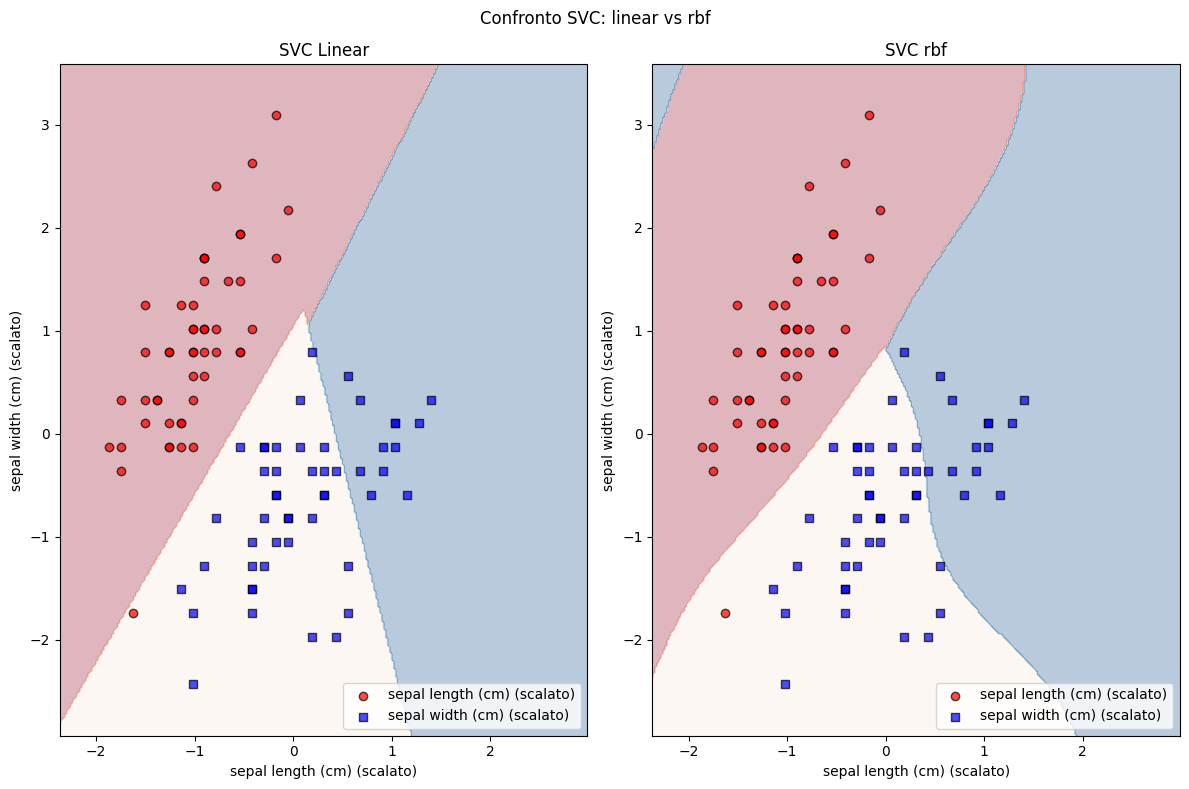

In [15]:
plt.figure(figsize = (12, 8))
plt.suptitle("Confronto SVC: linear vs rbf")

plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_linear, alpha= 0.3, cmap=plt.cm.RdBu)
plt.scatter(X_2d[y==0, 0], X_2d[y==0, 1], c ="red", edgecolors="k", marker="o", label=f"{data.feature_names[feature_0]} (scalato)", alpha = 0.7)
plt.scatter(X_2d[y==1, 0], X_2d[y==1, 1], c ="blue", edgecolors="k", marker="s", label=f"{data.feature_names[feature_1]} (scalato)", alpha = 0.7)
plt.title("SVC Linear")
plt.xlabel(f"{data.feature_names[feature_0]} (scalato)")
plt.ylabel(f"{data.feature_names[feature_1]} (scalato)")
plt.legend(loc="lower right")

plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_rbf, alpha= 0.3, cmap=plt.cm.RdBu)
plt.scatter(X_2d[y==0, 0], X_2d[y==0, 1], c ="red", edgecolors="k", marker="o", label=f"{data.feature_names[feature_0]} (scalato)", alpha = 0.7)
plt.scatter(X_2d[y==1, 0], X_2d[y==1, 1], c ="blue", edgecolors="k", marker="s", label=f"{data.feature_names[feature_1]} (scalato)", alpha = 0.7)
plt.title("SVC rbf")
plt.xlabel(f"{data.feature_names[feature_0]} (scalato)")
plt.ylabel(f"{data.feature_names[feature_1]} (scalato)")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [16]:
# verifichiamo differenze nell'accuratezza

tot_samples = len(y)
correct_lin = np.sum(y_pred_linear == y)
correct_rbf = np.sum(y_pred_rbf == y)

accuracy_lin = correct_lin / tot_samples
accuracy_rbf = correct_rbf / tot_samples

print(f"Accuracy linear:\t {accuracy_lin *100:.2f}% ({correct_lin} / {tot_samples})")
print(f"Accuracy linear:\t {accuracy_rbf *100:.2f}% ({correct_rbf} / {tot_samples})")



Accuracy linear:	 96.67% (145 / 150)
Accuracy linear:	 97.33% (146 / 150)
